In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from shapely.geometry import Polygon, MultiPolygon, Point

import geopandas as gpd

from qptifffile import QPTiffFile

from skimage.measure import find_contours
import tifffile

from rasterio.features import shapes
from shapely.geometry import shape

In [4]:
with QPTiffFile("E:/Tiziana_Hunner Lesion_Phenocycler/Full Scan of TMA/TC_fullTMA_20241001_Scan1.er.qptiff") as qptiff:

    print(qptiff.get_biomarkers())

['DAPI', 'CD31', 'CD4', 'Lyve-1', 'CD208', 'CD206', 'CD107a', 'CD45RO', 'aSMA', 'ICOS', 'PDGFRa', 'CD45', 'CD8a', 'CD79a', 'CD21', 'CTLA-4', 'CD20', 'CD86', 'CD11b', 'PD1', 'CD16', 'CD3e', 'CD163', 'FOXP3', 'CD14', 'Cytokeratin 8/18', 'Na/K ATPase', 'TCF1/7', 'Granzyme B', 'HLA-DR', 'CD19', 'CD68', 'MPO', 'B-actin', 'Ki67', 'PDL1', 'T-Bet', 'CD15', 'ctlCD8', 'Vimentin', 'DRAQ5', 'Mast']


In [24]:
anno = pd.read_csv("../../data/measurements_A2.tsv", sep="\t")

In [25]:
anno

,Image,Object ID,Object type,Name,Classification,Parent,ROI,Centroid X µm,Centroid Y µm,Nucleus: DAPI: Mean,...,Nucleus: Solidity,Nucleus: Max diameter µm,Nucleus: Min diameter µm,Cell: Area µm^2,Cell: Length µm,Cell: Circularity,Cell: Solidity,Cell: Max diameter µm,Cell: Min diameter µm,Nucleus/Cell area ratio
0,A-2.tif,9b4544b3-6e58-4a13-8630-fc39c7491363,Cell,NaN,Cellpose,Root object (Image),Polygon,474.86,259.46,1277.9434,...,1.0000,13.2821,6.6426,439.8385,82.3635,0.8148,0.9611,31.4332,19.5018,0.1544
1,A-2.tif,b5a2cb8e-360b-4189-bed9-62de5b3748ca,Cell,NaN,Cellpose,Root object (Image),Polygon,441.51,252.63,1904.7019,...,0.9916,17.6309,8.3503,424.9800,104.5018,0.4890,0.7864,42.6257,18.0405,0.2516
2,A-2.tif,0da44d2d-b4e4-4d70-bb33-5d58d542e612,Cell,NaN,Cellpose,Root object (Image),Polygon,194.35,805.29,1855.1520,...,0.9604,15.8787,6.0895,400.0611,84.4811,0.7044,0.9733,35.7715,15.6457,0.1828
3,A-2.tif,80d7e3a6-433b-4ffe-a8e1-fc5491d8fe58,Cell,NaN,Cellpose,Root object (Image),Polygon,449.80,273.90,1634.4149,...,0.9459,19.5445,8.1752,359.1094,81.9619,0.6718,0.9711,34.0634,13.3669,0.3015
4,A-2.tif,25de145f-118f-4498-bb5c-96595caef6d4,Cell,NaN,Cellpose,Root object (Image),Polygon,777.46,157.67,1197.4968,...,0.9518,8.4697,6.9348,359.0720,77.1977,0.7572,0.9738,31.9272,15.1726,0.1134
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10305,A-2.tif,911eba15-25f4-47f5-80a2-050bb92ef825,Cell,NaN,Cellpose,Root object (Image),Polygon,705.24,1293.10,1089.2727,...,1.0000,4.6018,2.4004,7.3365,11.4076,0.7085,1.0000,4.8100,2.2994,1.0000
10306,A-2.tif,48c9753f-627f-483e-99fc-aaac9c1d7be3,Cell,NaN,Cellpose,Root object (Image),Polygon,207.10,177.57,1163.4546,...,1.0000,2.5814,1.7978,8.1480,10.7530,0.8855,1.0000,3.7197,3.0030,0.3972
10307,A-2.tif,ea09f99d-377e-4c0a-aa15-4e8cbbddd68d,Cell,NaN,Cellpose,Root object (Image),Polygon,195.81,176.70,649.7037,...,1.0000,3.8172,2.1115,6.7509,9.9833,0.8512,0.9999,3.8405,2.5220,0.9067
10308,A-2.tif,1267cca1-76d9-4562-a34c-2a3ecbfb95c2,Cell,NaN,Cellpose,Root object (Image),Polygon,199.93,615.85,1002.0000,...,1.0000,3.0020,2.2207,6.0229,9.5711,0.8262,1.0000,3.6137,2.5108,0.7258


In [6]:
anno.head(10).to_excel("measurements_A2.xlsx", index=False)

In [36]:
anno = anno.sort_values(["Centroid X µm", "Centroid Y µm"], ascending=[True, True]).reset_index(drop=True)

In [37]:
anno

,Image,Object ID,Object type,Name,Classification,Parent,ROI,Centroid X µm,Centroid Y µm,Nucleus: DAPI: Mean,...,Nucleus: Solidity,Nucleus: Max diameter µm,Nucleus: Min diameter µm,Cell: Area µm^2,Cell: Length µm,Cell: Circularity,Cell: Solidity,Cell: Max diameter µm,Cell: Min diameter µm,Nucleus/Cell area ratio
0,A-2.tif,4f8a6ecb-8ffc-4c8e-bedc-6241aa2848dd,Cell,NaN,Cellpose,Root object (Image),Polygon,1.298,758.66,2064.0000,...,1.0000,3.6204,1.4990,14.7569,15.7907,0.7437,1.0000,6.3790,2.9979,0.2653
1,A-2.tif,ee2b7979-f3e0-4d9b-a170-0c534e4901e6,Cell,NaN,Cellpose,Root object (Image),Polygon,1.545,790.19,3128.8262,...,1.0000,5.7976,2.6992,25.3761,22.7230,0.6176,0.9707,9.6903,3.6006,0.4983
2,A-2.tif,06665007-43a9-4a1b-b0ca-7712f8582d5d,Cell,NaN,Cellpose,Root object (Image),Polygon,1.949,721.95,1459.2195,...,1.0000,4.8853,2.9218,21.1323,17.5410,0.8631,1.0000,6.2160,4.1981,0.4773
3,A-2.tif,55c6d455-f5dc-4756-8c09-d09834bc2c61,Cell,NaN,Cellpose,Root object (Image),Polygon,1.973,540.67,800.6667,...,1.0000,3.3541,1.8028,23.5911,20.1986,0.7266,0.9739,7.7196,4.2032,0.1911
4,A-2.tif,4f3c1185-3e5c-434d-a1b8-6b694bf4a914,Cell,NaN,Cellpose,Root object (Image),Polygon,2.191,766.42,1840.6500,...,1.0000,6.8390,3.6006,41.6317,25.9394,0.7775,1.0000,10.3572,4.8008,0.4994
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10305,A-2.tif,d9df3c3f-73fe-4a14-8136-b3e32642ce95,Cell,NaN,Cellpose,Root object (Image),Polygon,1311.500,555.47,1240.9354,...,0.9205,4.6852,2.3927,28.6163,20.0082,0.8983,0.9814,6.8762,5.7018,0.2564
10306,A-2.tif,54dafce2-6e19-4092-bd99-70943e18bd73,Cell,NaN,Cellpose,Root object (Image),Polygon,1312.100,666.33,1967.9269,...,0.9663,8.9219,4.7429,102.1225,38.2926,0.8752,0.9619,12.8059,10.8797,0.3020
10307,A-2.tif,db440619-3ae9-4dc1-9c3e-57385010f0b4,Cell,NaN,Cellpose,Root object (Image),Polygon,1312.100,666.33,2067.9438,...,0.9621,8.3853,4.8486,102.1225,38.2926,0.8752,0.9619,12.8059,10.8797,0.2802
10308,A-2.tif,969e607e-9ed3-414d-9653-68426eac931f,Cell,NaN,Cellpose,Root object (Image),Polygon,1312.600,548.84,3438.6924,...,1.0000,4.9981,2.9153,36.6689,22.4259,0.9162,1.0000,8.1892,5.9042,0.2826


In [ ]:
anno_gdf = gpd.GeoDataFrame(anno, geometry=gpd.points_from_xy(anno["Centroid X µm"] / 0.5055, anno["Centroid Y µm"] / 0.5055))

In [59]:
len(anno)

10310

<Axes: >

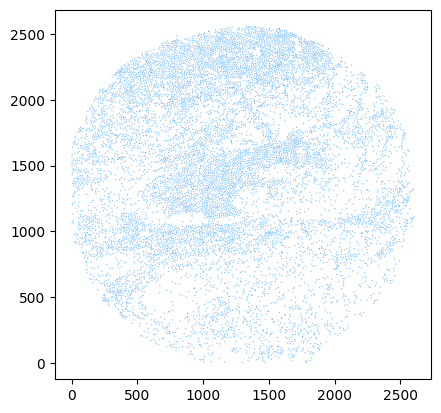

In [77]:
anno_gdf.plot(markersize=1, edgecolor="None", color="dodgerblue", alpha=0.5)

In [2]:
masks = tifffile.imread("../../data/A-2_mask_cellmembrane.tif")

In [49]:
len(masks)

2556

In [ ]:
for cell in np.unique(masks):
    if cell == 0:
        continue

    if cell == 1:
        contour = find_contours(masks == cell, 0.5)[0]

        

In [7]:
contour

array([[1939.5, 1729. ],
       [1939.5, 1728. ],
       [1939.5, 1727. ],
       [1939. , 1726.5],
       [1938.5, 1726. ],
       [1938. , 1725.5],
       [1937.5, 1725. ],
       [1937. , 1724.5],
       [1936.5, 1724. ],
       [1936. , 1723.5],
       [1935.5, 1723. ],
       [1935. , 1722.5],
       [1934. , 1722.5],
       [1933. , 1722.5],
       [1932. , 1722.5],
       [1931.5, 1722. ],
       [1931. , 1721.5],
       [1930. , 1721.5],
       [1929.5, 1722. ],
       [1929. , 1722.5],
       [1928. , 1722.5],
       [1927.5, 1723. ],
       [1927. , 1723.5],
       [1926. , 1723.5],
       [1925.5, 1724. ],
       [1925.5, 1725. ],
       [1925. , 1725.5],
       [1924.5, 1726. ],
       [1924. , 1726.5],
       [1923.5, 1727. ],
       [1923.5, 1728. ],
       [1923. , 1728.5],
       [1922.5, 1729. ],
       [1922.5, 1730. ],
       [1922.5, 1731. ],
       [1922. , 1731.5],
       [1921.5, 1732. ],
       [1921.5, 1733. ],
       [1921.5, 1734. ],
       [1921.5, 1735. ],


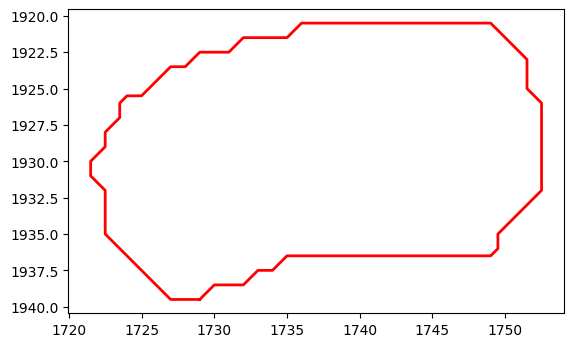

In [9]:
plt.plot(contour[:, 1], contour[:, 0], "r-", linewidth=2)
plt.gca().invert_yaxis()
plt.gca().set_aspect("equal")

In [13]:
masks_int = masks.astype(np.int32)

records = []

for geometry_mapping, cell_id in shapes(
    masks_int,
    mask=masks_int > 0
):
    cell_id = int(cell_id)

    if cell_id == 0:
        continue

    polygon = shape(geometry_mapping)

    records.append(
        {
            "cell_id": cell_id,
            "geometry": polygon
        }
    )

cells_gdf = gpd.GeoDataFrame(
    records,
    geometry="geometry"
)

In [14]:
print(cells_gdf.head())
print("Number of polygon records:", len(cells_gdf))

   cell_id                                           geometry
0     9343  POLYGON ((1466 1, 1466 5, 1473 5, 1473 3, 1474...
1     4078  POLYGON ((1299 0, 1299 1, 1284 1, 1284 5, 1286...
2     3094  POLYGON ((1002 3, 1002 4, 1001 4, 1001 5, 1000...
3     5204  POLYGON ((1778 0, 1778 1, 1777 1, 1777 2, 1776...
4     9601  POLYGON ((1151 0, 1151 1, 1150 1, 1150 2, 1148...
Number of polygon records: 10066


In [15]:
cells_gdf = cells_gdf.dissolve(
    by="cell_id",
    as_index=False
)

In [16]:
print("Number of unique cells:", len(cells_gdf))

Number of unique cells: 10056


In [17]:
cells_gdf["x"] = cells_gdf.geometry.centroid.x
cells_gdf["y"] = cells_gdf.geometry.centroid.y

In [31]:
cells_gdf = cells_gdf.sort_values(by=["x", "y"], ascending=[True, True]).reset_index(drop=True)

In [32]:
print(cells_gdf.head())

   cell_id                                           geometry         x  \
0     8482  POLYGON ((1 1492, 1 1494, 0 1494, 0 1503, 1 15...  2.822034   
1     8071  POLYGON ((1 1551, 1 1552, 0 1552, 0 1567, 1 15...  3.398148   
2     8968  POLYGON ((2 1420, 2 1421, 1 1421, 1 1423, 0 14...  4.166667   
3      158  POLYGON ((1 1061, 1 1074, 2 1074, 2 1076, 5 10...  4.361702   
4     6462  POLYGON ((1 1504, 1 1506, 0 1506, 0 1522, 1 15...  4.610465   

             y  
0  1498.533898  
1  1560.722222  
2  1426.244444  
3  1068.223404  
4  1513.918605  


In [33]:
len(cells_gdf)

10056

<Axes: >

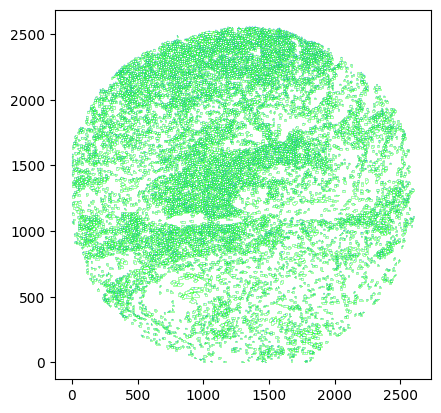

In [99]:
cells_gdf.plot(edgecolor="lime", color="None", alpha=0.5, linewidth=0.5)

anno_gdf.plot(markersize=1, edgecolor="None", color="dodgerblue", alpha=0.5, ax=plt.gca())

In [105]:
combined_gdf = cells_gdf.rename_geometry("membrane_geometry").sjoin(anno_gdf.rename_geometry("centroid_geometry"), how="right", predicate="intersects")

In [100]:
combined_gdf = cells_gdf.sjoin(anno_gdf, how="left", predicate="within")

<Axes: >

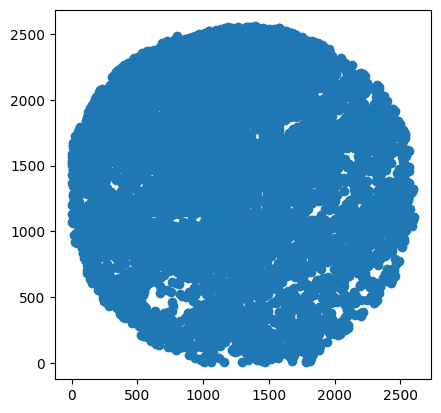

In [106]:
combined_gdf.plot()

In [109]:
combined_gdf[~combined_gdf["cell_id"].isna()]

,index_left,cell_id,x,y,Image,Object ID,Object type,Name,Classification,Parent,...,Nucleus: Max diameter µm,Nucleus: Min diameter µm,Cell: Area µm^2,Cell: Length µm,Cell: Circularity,Cell: Solidity,Cell: Max diameter µm,Cell: Min diameter µm,Nucleus/Cell area ratio,centroid_geometry
0,0.0,8482.0,2.822034,1498.533898,A-2.tif,4f8a6ecb-8ffc-4c8e-bedc-6241aa2848dd,Cell,NaN,Cellpose,Root object (Image),...,3.6204,1.4990,14.7569,15.7907,0.7437,1.0000,6.3790,2.9979,0.2653,POINT (2.568 1500.811)
1,1.0,8071.0,3.398148,1560.722222,A-2.tif,ee2b7979-f3e0-4d9b-a170-0c534e4901e6,Cell,NaN,Cellpose,Root object (Image),...,5.7976,2.6992,25.3761,22.7230,0.6176,0.9707,9.6903,3.6006,0.4983,POINT (3.056 1563.185)
2,2.0,8968.0,4.166667,1426.244444,A-2.tif,06665007-43a9-4a1b-b0ca-7712f8582d5d,Cell,NaN,Cellpose,Root object (Image),...,4.8853,2.9218,21.1323,17.5410,0.8631,1.0000,6.2160,4.1981,0.4773,POINT (3.856 1428.19)
3,3.0,158.0,4.361702,1068.223404,A-2.tif,55c6d455-f5dc-4756-8c09-d09834bc2c61,Cell,NaN,Cellpose,Root object (Image),...,3.3541,1.8028,23.5911,20.1986,0.7266,0.9739,7.7196,4.2032,0.1911,POINT (3.903 1069.575)
4,4.0,6462.0,4.610465,1513.918605,A-2.tif,4f3c1185-3e5c-434d-a1b8-6b694bf4a914,Cell,NaN,Cellpose,Root object (Image),...,6.8390,3.6006,41.6317,25.9394,0.7775,1.0000,10.3572,4.8008,0.4994,POINT (4.334 1516.162)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10305,10052.0,848.0,2590.252294,1097.279817,A-2.tif,d9df3c3f-73fe-4a14-8136-b3e32642ce95,Cell,NaN,Cellpose,Root object (Image),...,4.6852,2.3927,28.6163,20.0082,0.8983,0.9814,6.8762,5.7018,0.2564,POINT (2594.461 1098.853)
10306,10053.0,8746.0,2591.495000,1316.165000,A-2.tif,54dafce2-6e19-4092-bd99-70943e18bd73,Cell,NaN,Cellpose,Root object (Image),...,8.9219,4.7429,102.1225,38.2926,0.8752,0.9619,12.8059,10.8797,0.3020,POINT (2595.648 1318.16)
10307,10053.0,8746.0,2591.495000,1316.165000,A-2.tif,db440619-3ae9-4dc1-9c3e-57385010f0b4,Cell,NaN,Cellpose,Root object (Image),...,8.3853,4.8486,102.1225,38.2926,0.8752,0.9619,12.8059,10.8797,0.2802,POINT (2595.648 1318.16)
10308,10054.0,8481.0,2592.416667,1084.215278,A-2.tif,969e607e-9ed3-414d-9653-68426eac931f,Cell,NaN,Cellpose,Root object (Image),...,4.9981,2.9153,36.6689,22.4259,0.9162,1.0000,8.1892,5.9042,0.2826,POINT (2596.637 1085.737)


<Axes: >

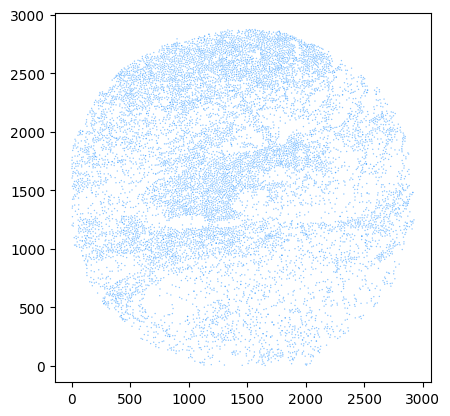

In [62]:
anno_gdf.plot(markersize=1, edgecolor="None", color="dodgerblue", alpha=0.5)

Text(0, 0.5, 'Y coordinate (pixels)')

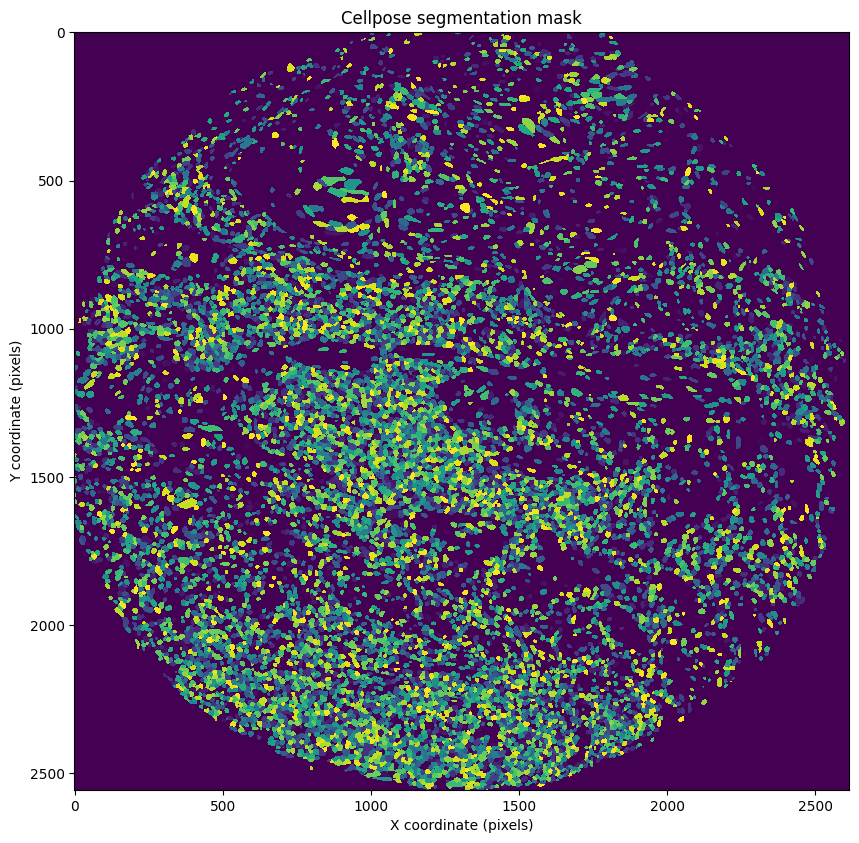

In [23]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(masks, interpolation="none")

ax.set_title("Cellpose segmentation mask")
ax.set_xlabel("X coordinate (pixels)")
ax.set_ylabel("Y coordinate (pixels)")

(2556.0, 0.0)

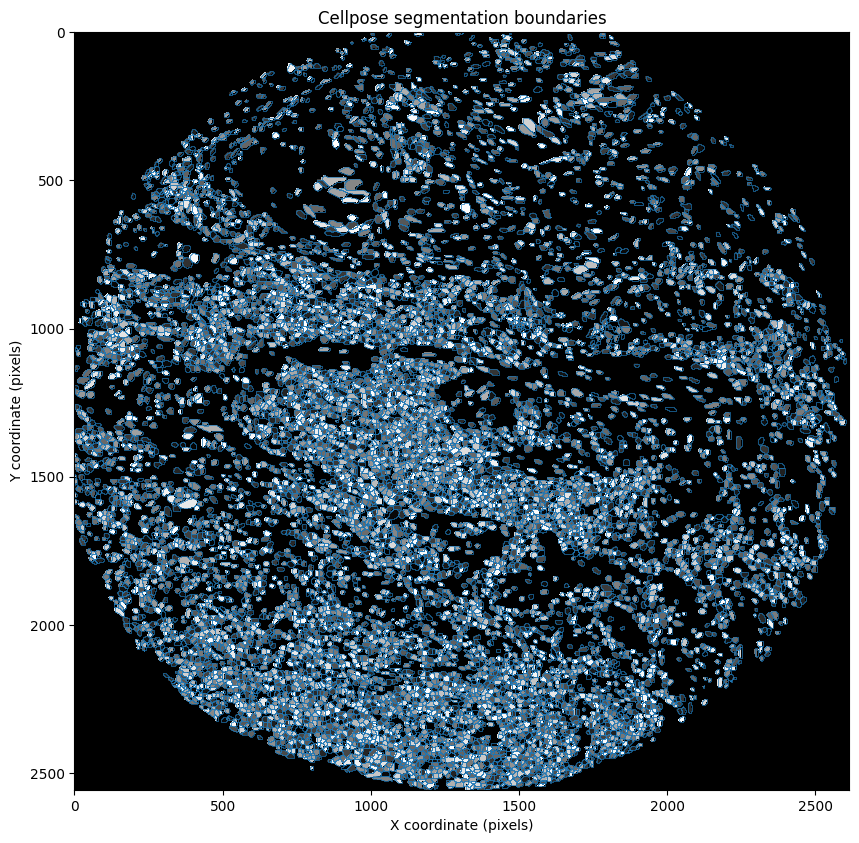

In [20]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(
    masks,
    cmap="gray",
    interpolation="none"
)

cells_gdf.boundary.plot(
    ax=ax,
    linewidth=0.5
)

ax.set_title("Cellpose segmentation boundaries")
ax.set_xlabel("X coordinate (pixels)")
ax.set_ylabel("Y coordinate (pixels)")

# Keep image coordinates, where y increases downward
ax.set_xlim(0, masks.shape[1])
ax.set_ylim(masks.shape[0], 0)

In [112]:
cell_data = pd.read_csv("../../data/measurements_A2.tsv", sep="\t")
cell_gdf = gpd.GeoDataFrame(cell_data, geometry=gpd.points_from_xy(cell_data["Centroid X µm"] / 0.5055, cell_data["Centroid Y µm"] / 0.5055))


masks = tifffile.imread("../../data/A-2_mask_cellmembrane.tif")


masks_int = masks.astype(np.int32)

records = []

for geometry_mapping, cell_id in shapes(
    masks_int,
    mask=masks_int > 0
):
    cell_id = int(cell_id)

    if cell_id == 0:
        continue

    polygon = shape(geometry_mapping)

    records.append(
        {
            "cell_id": cell_id,
            "geometry": polygon
        }
    )

anno_gdf = gpd.GeoDataFrame(
    records,
    geometry="geometry"
)

anno_gdf = anno_gdf.dissolve(
    by="cell_id",
    as_index=False
)

combined_gdf = cell_gdf.rename_geometry("membrane_geometry").sjoin(anno_gdf.rename_geometry("centroid_geometry"), how="left", predicate="intersects")

combined_gdf = gpd.GeoDataFrame(combined_gdf, geometry="membrane_geometry")

In [113]:
combined_gdf

,Image,Object ID,Object type,Name,Classification,Parent,ROI,Centroid X µm,Centroid Y µm,Nucleus: DAPI: Mean,...,Cell: Area µm^2,Cell: Length µm,Cell: Circularity,Cell: Solidity,Cell: Max diameter µm,Cell: Min diameter µm,Nucleus/Cell area ratio,membrane_geometry,index_right,cell_id
0,A-2.tif,9b4544b3-6e58-4a13-8630-fc39c7491363,Cell,NaN,Cellpose,Root object (Image),Polygon,474.86,259.46,1277.9434,...,439.8385,82.3635,0.8148,0.9611,31.4332,19.5018,0.1544,POINT (939.387 513.274),5241.0,5435.0
1,A-2.tif,b5a2cb8e-360b-4189-bed9-62de5b3748ca,Cell,NaN,Cellpose,Root object (Image),Polygon,441.51,252.63,1904.7019,...,424.9800,104.5018,0.4890,0.7864,42.6257,18.0405,0.2516,POINT (873.412 499.763),7342.0,7578.0
2,A-2.tif,0da44d2d-b4e4-4d70-bb33-5d58d542e612,Cell,NaN,Cellpose,Root object (Image),Polygon,194.35,805.29,1855.1520,...,400.0611,84.4811,0.7044,0.9733,35.7715,15.6457,0.1828,POINT (384.471 1593.056),9135.0,9387.0
3,A-2.tif,80d7e3a6-433b-4ffe-a8e1-fc5491d8fe58,Cell,NaN,Cellpose,Root object (Image),Polygon,449.80,273.90,1634.4149,...,359.1094,81.9619,0.6718,0.9711,34.0634,13.3669,0.3015,POINT (889.812 541.84),6396.0,6613.0
4,A-2.tif,25de145f-118f-4498-bb5c-96595caef6d4,Cell,NaN,Cellpose,Root object (Image),Polygon,777.46,157.67,1197.4968,...,359.0720,77.1977,0.7572,0.9738,31.9272,15.1726,0.1134,POINT (1538.002 311.909),8280.0,8525.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10305,A-2.tif,911eba15-25f4-47f5-80a2-050bb92ef825,Cell,NaN,Cellpose,Root object (Image),Polygon,705.24,1293.10,1089.2727,...,7.3365,11.4076,0.7085,1.0000,4.8100,2.2994,1.0000,POINT (1395.134 2558.061),NaN,NaN
10306,A-2.tif,48c9753f-627f-483e-99fc-aaac9c1d7be3,Cell,NaN,Cellpose,Root object (Image),Polygon,207.10,177.57,1163.4546,...,8.1480,10.7530,0.8855,1.0000,3.7197,3.0030,0.3972,POINT (409.693 351.276),7373.0,7609.0
10307,A-2.tif,ea09f99d-377e-4c0a-aa15-4e8cbbddd68d,Cell,NaN,Cellpose,Root object (Image),Polygon,195.81,176.70,649.7037,...,6.7509,9.9833,0.8512,0.9999,3.8405,2.5220,0.9067,POINT (387.359 349.555),2492.0,2617.0
10308,A-2.tif,1267cca1-76d9-4562-a34c-2a3ecbfb95c2,Cell,NaN,Cellpose,Root object (Image),Polygon,199.93,615.85,1002.0000,...,6.0229,9.5711,0.8262,1.0000,3.6137,2.5108,0.7258,POINT (395.509 1218.299),7822.0,8063.0
